# Focusing apodized grating coupler

**Running the entire notebook costs more than 1 FlexCredit.**

In this notebook, we will design a focusing apodized grating coupler (GC) to vertically couple light in/out photonic integrated circuits (PICs). We will build the grating coupler following the design guidelines presented in the following paper: R. Marchetti, C. Lacava, A. Khokhar, et al. "High-efficiency grating-couplers: demonstration of a new design strategy," Sci Rep 7, 16670 (2017) [DOI: 10.1038/s41598-017-16505-z](https://doi.org/10.1038/s41598-017-16505-z). In a previous case study, we modeled an [uniform grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/GratingCoupler/). The apodized grating coupler demonstrated in this notebook shows superior performance.

For more integrated photonic examples such as the [8-Channel mode and polarization de-multiplexer](https://www.flexcompute.com/tidy3d/examples/notebooks/8ChannelDemultiplexer/), the [broadband bi-level taper polarization rotator-splitter](https://www.flexcompute.com/tidy3d/examples/notebooks/BilevelPSR/), and the [broadband directional coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/BroadbandDirectionalCoupler/), please visit our [examples page](https://www.flexcompute.com/tidy3d/examples/).

If you are new to the finite-difference time-domain (FDTD) method, we highly recommend going through our [FDTD101](https://www.flexcompute.com/fdtd101/) tutorials. 

FDTD simulations can diverge due to various reasons. If you run into any simulation divergence issues, please follow the steps outlined in our [troubleshooting guide](https://www.flexcompute.com/tidy3d/examples/notebooks/DivergedFDTDSimulation/) to resolve it. 

In [1]:
# Standard python imports.
import gdstk
import matplotlib.pylab as plt
import numpy as np

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins import waveguide

## Grating Coupler Structure

The GC structure is based on a standard silicon-on-insulator (SOI) wafer with a device layer of 220 nm. By linearly varying the fill-factor $F(x) = F_{0} - R\cdot x$, where $F_{0}$ is the fill-factor of the first grating element and $R$ is the apodization factor, the power radiated by the first elements of the grating is reduced, and the mode matching between the output waveguide and the grating section is improved, thus reducing reflections. To further improve the grating coupling efficiency, the grating element size $\Delta$ is let to vary, so satisfying the Bragg condition along the whole grating. 

<center><img src="img/FocusedGC.png" alt="Focused Apodized Grating Coupler"  width="700"/></center>

The effective index of a grating element $n_{eff}(x)$ then depends on the fill-factor $F(x)$, and the mode indices obtained in the etched ($n_{e}$) and non-etched ($n_{o}$) sections of the grating, as 

\begin{equation*}
n_{eff}(x) = F(x)n_{o} + [1 - F(x)]n_{e}.
\tag{1}
\end{equation*}

From the effective index, the size of each grating element can be calculated as:

\begin{equation*}
\Delta(x) = \frac{\lambda_{0}}{n_{e} - n_{c}sin(\theta_{gc}) + F(x)\Delta n}
\tag{2}
\end{equation*}

where $\lambda_{0}$ is the center wavelength, $n_{c}$ is the cladding refractive index, $\theta_{gc}$ is the light incidence angle with respect to the grating normal, and $\Delta n = n_{o} - n_{e}$. 

A focusing design of GC is usually adopted to reduce device footprint. In this way, the grating lines (indicated by an integer $q$) are curved forming ellipses with common focal points, as in Eq. 3 (`Ralf Waldhäusl, Bernd Schnabel, Peter Dannberg, Ernst-Bernhard Kley, Andreas Bräuer, and Wolfgang Karthe, "Efficient Coupling into Polymer Waveguides by Gratings," Appl. Opt. 36, 9383-9390 (1997)`[DOI: 10.1364/AO.36.009383](https://doi.org/10.1364/AO.36.009383)).

\begin{equation*}
q\lambda_{0} = n_{eff}\sqrt{x^{2} + y^{2}} - xn_{c}sin(\theta_{f}).
\tag{3}
\end{equation*}

For simplicity, we will approximate the grating lines by concentric circles, which is a reasonable assumption considering small incidence angles.

In [2]:
# Grating coupler set up.
h_dev = 0.40  # Device layer thickness (um).
h_box = 5.0  # BOX layer thickness (um).
h_clad = 5.0  # Cladding layer thickness (um).
h_sub = 1.0  # Silicon substrate thickness (um).
etch_d = 0.4  # GC etch depth (um).
alpha_t = 40  # GC taper opening angle (degrees).
tap_l = 1222.368  # Taper length (um).
tap_e = 1  # Additional length after GC elements (um).
n_p = 25  # Number of grating elements.
r_i = 0.0275  # Initial value for the apodization parameter.
min_feature = 0.1  # Minimum feature size (um).
spot_size = 9.0  # Single-mode fiber (SMF) spot-size (um).
theta_f = 8  # Fiber tilt angle w.r.t the z-axis (degrees).
src_pos = 5.0  # Source position w.r.t the position of the first GC line (um).
src_offset = 0.05  # Source offset w.r.t GC surface (um).
wg_l = 1.0  # Output waveguide length (um).
wg_w = 0.8  # Output waveguide width (um).
gc_file = "gc_only.gds"  # File name to export GC GDS file.

# Materials.
n_si = 3.48  # Silicon refractive index.
n_si3n4 = 1.96274
n_sio2 = 1.44384
n_c = n_sio2  # Cladding refractive index.

# Simulation set up.
wl = 1.31  # Center simulation wavelength (um).
bw = 0.1  # Simulation wavelength bandwidth (um).
n_wl = 101  # Number of wavelength points in monitors.
run_time = 4e-12  # Run time parameter for simulation (s).

We will calculate and define some parameters used throughout the notebook.

In [3]:
# Material definitions.
mat_si = td.Medium(permittivity=n_si**2)  # Waveguide material.
mat_sio2 = td.Medium(permittivity=n_sio2**2)  # BOX material.
mat_clad = td.Medium(permittivity=n_c**2)  # Cladding material.
mat_si3n4 = td.Medium(permittivity=n_si3n4**2)  # Si3N4 material.

# Light incidence angle on the GC.
theta_gc = np.arcsin(np.sin(theta_f * np.pi / 180) / n_c) * 180 / np.pi

# Wavelengths and frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])

So, let's define some functions to create the grating coupler.


##  Simulation Set Up

We will create a function to build different types of simulations based on the value of `sim_mode`:

- `sim_mode = "sweep"`: *builds an in-coupling simulation using only one mode monitor.*
- `sim_mode = "visualization"`: *builds an in-coupling simulation including field and flux monitors.*
- `sim_mode = "out_coupling"`: *builds an out-coupling simulation using a field projection monitor.*

To define the grating structure, we will perform 2D simulations by running multiple parameter sweeps. Once this is completed, the final response will be obtained using 3D simulations. Details about setting up 2D simulations can be found in the [2D ring resonator notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/RingResonator/).

In [8]:
# Function to create the simulation.
def build_sim(
    sim_mode="sweep",
    sim_dim="3D",
    src_pos=src_pos,
    alpha_t=alpha_t,
    tap_l=tap_l,
    etch_d=etch_d,
    gds_file=[],
):
    print(gds_file)
    # Build the Tidy3D PolySlab and Structure objects.
    # Get design cell from GDSII file
    gds_path  = gds_file  # File name to export GC GDS file.
    lib_loaded = gdstk.read_gds(gds_path)
    all_cells = {c.name: c for c in lib_loaded.cells}
    print("Cell names: " + ", ".join(all_cells.keys()))
    des_cell = all_cells["GC"]
    print(des_cell)

    gc_cell = des_cell
    wg_t = h_dev  # Waveguide thickness (um).
    etch_d = h_dev  # Etch depth (um).
    wg_l = 1.0
    gc_length = 1316.923 - wg_l # Length of the grating coupler (um).
    print("gc_length: ", gc_length)

    # Calculate the grating coupler parameters.
    gc = td.Geometry.from_gds(
        gc_cell,
        gds_layer=733,
        gds_dtype=727,
        axis=2,
        slab_bounds=(-wg_t / 2, wg_t / 2),
        reference_plane = "bottom",
    )
    gc_struct = td.Structure(
        geometry=gc, medium=mat_si3n4
    )
    gc_offset = wg_w/np.tan(alpha_t*np.pi/180)
    gc_0 = wg_l + tap_l - gc_offset

    # gc_length = tap_l + np.sum(del_x) + tap_e  - gc_offset
    pml_offset = 0.7 * wl
    
    # Simulation size.
    size_z = h_sub + h_box + h_dev + h_clad + pml_offset
    size_x = wg_l + gc_length + wl
    size_y = 0.95 * gc_length * np.tan(alpha_t * np.pi / 180) if sim_dim == "3D" else 0
    center_z = size_z / 2 - pml_offset - h_clad - h_dev / 2

    # Box layer.
    _inf = 1500
    sio2_box = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-_inf, -_inf, -h_dev / 2 - h_box), rmax=(_inf, _inf, -h_dev / 2)
        ),
        medium=mat_sio2,
    )
    # Cladding layer.
    cladding = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-_inf, -_inf, -h_dev / 2), rmax=(_inf, _inf, h_dev / 2 + h_clad)
        ),
        medium=mat_clad,
    )
    # Substrate.
    si_sub = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-_inf, -_inf, -_inf), rmax=(_inf, _inf, -h_dev / 2 - h_box)
        ),
        medium=mat_si,
    )

    if sim_mode == "sweep" or sim_mode == "visualization":
        # Gaussian source focused above the grating coupler.
        # source = td.GaussianBeam(
        #     center=(gc_0 + src_pos, 0, h_dev / 2 + h_clad + src_offset),
        #     size=(
        #         1.2 * spot_size,
        #         1.2 * spot_size if sim_dim == "3D" else td.inf,  # Make it infinity in 2D.
        #         0,
        #     ),
        #     source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
        #     pol_angle=np.pi / 2,
        #     angle_theta=theta_f * np.pi / 180.0,
        #     direction="-",
        #     num_freqs=7,
        #     waist_radius=spot_size / 2,
        # )
        # Mode monitor.
        mode_spec = td.ModeSpec(num_modes=1, target_neff=n_si3n4)
        mode_monitor = td.ModeMonitor(
            center=[0.5 * wl, 0, 0],
            size=[0, 4 * wg_w, 5 * h_dev],
            freqs=freqs,
            mode_spec=mode_spec,
            name="mode_monitor",
        )
        monitors = [mode_monitor]

        if sim_mode == "visualization":
            # Add field and flux monitors.
            field_monitor_xy = td.FieldMonitor(
                center=(size_x / 2, 0, h_dev / 2 - etch_d / 2),
                size=(td.inf, td.inf, 0),
                freqs=[freq],
                name="field_xy",
            )
            monitors.append(field_monitor_xy)
            field_monitor_xz = td.FieldMonitor(
                center=(size_x / 2, 0, 0),
                size=(td.inf, 0, td.inf),
                freqs=[freq],
                name="field_xz",
            )
            monitors.append(field_monitor_xz)
            flux_sub = td.FluxMonitor(
                center=(size_x / 2, 0, -h_dev - h_box),
                size=(td.inf, td.inf, 0),
                freqs=freqs,
                name="flux_sub",
            )
            monitors.append(flux_sub)
            flux_ref = td.FluxMonitor(
                center=(size_x / 2, 0, h_dev + h_clad + src_offset),
                size=(td.inf, td.inf, 0),
                freqs=freqs,
                name="flux_reflected",
            )
            monitors.append(flux_ref)
    else:
        # Define a mode source that injects te fundamental mode.
        mode_spec = td.ModeSpec(num_modes=1, target_neff=n_si3n4)
        source = td.ModeSource(
            center=(0.5 * wl, 0, 0),
            size=(0, 4 * wg_w, 5 * h_dev),
            source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
            direction="+",
            mode_spec=mode_spec,
            mode_index=0,
            num_freqs=7,
        )
        # Add a near field monitor.
        field_monitor_xy = td.FieldMonitor(
            center=(size_x / 2, 0, h_dev / 2 + h_clad + src_offset),
            size=(td.inf, td.inf, 0),
            freqs=[freq],
            name="near_field",
        )
        monitors = [field_monitor_xy]
        field_monitor_xz = td.FieldMonitor(
            center=(size_x / 2, 0, 0),
            size=(td.inf, 0, td.inf),
            freqs=[freq],
            name="field_xz",
        )
        monitors.append(field_monitor_xz)
        flux_back = td.FluxMonitor(
            center=(0.25 * wl, 0, 0),
            size=(0, td.inf, td.inf),
            freqs=freqs,
            name="flux_back",
        )
        monitors.append(flux_back)

    # Refine the grid over the GC region.
    refine_box = td.MeshOverrideStructure(
        geometry=td.Box(center=(size_x / 2, 0, 0), size=(td.inf, td.inf, 2 * h_dev)),
        dl=[0.02, 0.02 if sim_dim == "3D" else None, 0.02],
    )

    # Simulation
    sim = td.Simulation(
        center=(size_x / 2, 0, -center_z),
        size=(size_x, size_y, size_z),
        grid_spec=td.GridSpec.auto(
            wavelength=wl,
            min_steps_per_wvl=15,
            override_structures=[refine_box],
        ),
        structures=[si_sub, sio2_box, cladding, gc_struct],
        sources=[source],
        monitors=monitors,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.pml()
            if sim_dim == "3D"
            else td.Boundary.periodic(),  # Make it periodic in 2D.
            z=td.Boundary.pml(),
        ),
        symmetry=(0, -1 if sim_dim == "3D" else 0, 0),
        run_time=run_time,
    )
    return sim

### Grating Coupler Visualization

To verify if everything is correct, we will obtain the parameters $n_{o}$ and $n_{e}$, calculated using the `waveguide` plugin, and then visualize the grating coupler structure.

23:11:17 Eastern Daylight Time WARNING: Structure: simulation.structures[2] (no 
                               `name` was specified) has geometry with zero size
                               along dimensions [2], and with a medium that is  
                               not a 'Medium2D'. This is probably not correct,  
                               since the resulting simulation will depend on the
                               details of the numerical grid. Consider either   
                               giving the geometry a nonzero thickness or using 
                               a 'Medium2D'.                                    

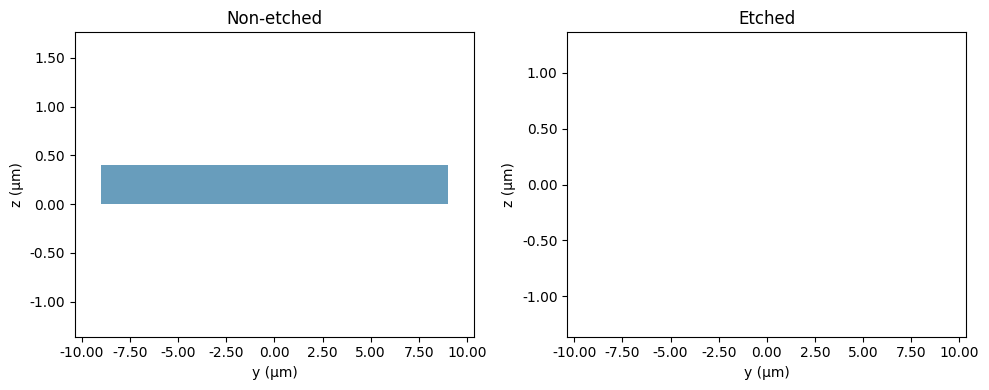

In [5]:
# Definition of wide non-etched and etched waveguides.
wg_non_etch, wg_etch = (
    waveguide.RectangularDielectric(
        wavelength=wl,
        core_width=2 * spot_size,
        core_thickness=t,
        core_medium=mat_si3n4,
        box_medium=mat_sio2,
        clad_medium=mat_clad,
    )
    for t in [h_dev, 0]
)

# Take a look at the waveguide cross-sections.
fig, ax = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
_ = wg_non_etch.plot_structures(x=0, ax=ax[0])
ax[0].set_aspect("auto")
ax[0].set_title("Non-etched")
_ = wg_etch.plot_structures(x=0, ax=ax[1])
ax[1].set_aspect("auto")
ax[1].set_title("Etched")
plt.show()

23:11:39 Eastern Daylight Time WARNING: Structure: simulation.structures[2] (no 
                               `name` was specified) has geometry with zero size
                               along dimensions [2], and with a medium that is  
                               not a 'Medium2D'. This is probably not correct,  
                               since the resulting simulation will depend on the
                               details of the numerical grid. Consider either   
                               giving the geometry a nonzero thickness or using 
                               a 'Medium2D'.                                    

                               WARNING: Structure: simulation.structures[2] (no 
                               `name` was specified) has geometry with zero size
                               along dimensions [2], and with a medium that is  
                               not a 'Medium2D'. This is probably not correct,  
                               since the resulting simulation will depend on the
                               details of the numerical grid. Consider either   
                               giving the geometry a nonzero thickness or using 
                               a 'Medium2D'.                                    

23:11:45 Eastern Daylight Time WARNING: Mode field at frequency index 0, mode   
                               index 0 does not decay at the plane boundaries.  

                               WARNING: Mode field at frequency index 0, mode   
                               index 1 does not decay at the plane boundaries.  

Non-etched waveguide effective index: 1.753
Etched waveguide effective index: 1.443


23:11:47 Eastern Daylight Time WARNING: Structure: simulation.structures[2] (no 
                               `name` was specified) has geometry with zero size
                               along dimensions [2], and with a medium that is  
                               not a 'Medium2D'. This is probably not correct,  
                               since the resulting simulation will depend on the
                               details of the numerical grid. Consider either   
                               giving the geometry a nonzero thickness or using 
                               a 'Medium2D'.                                    

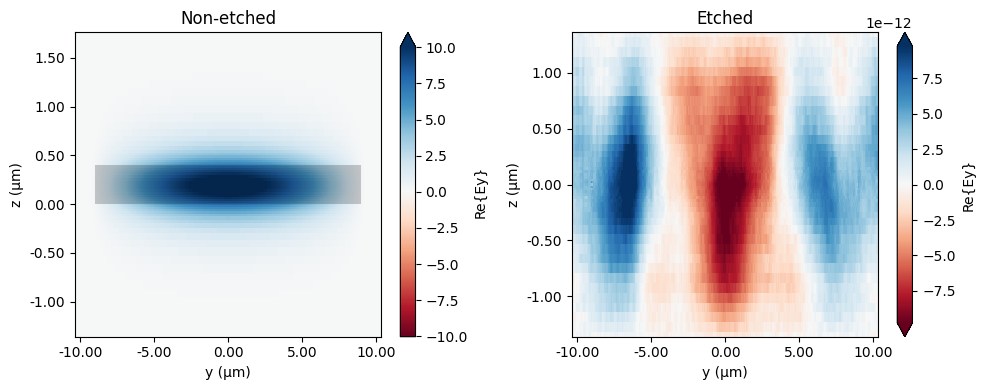

In [6]:
n_o = wg_non_etch.n_eff.values[0, 0]
n_e = wg_etch.n_eff.values[0, 0]
print(f"Non-etched waveguide effective index: {n_o:.3f}")
print(f"Etched waveguide effective index: {n_e:.3f}")

# Take a look at the waveguide fields.
fig, ax = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
wg_non_etch.plot_field("Ey", mode_index=0, ax=ax[0])
ax[0].set_aspect("auto")
ax[0].set_title("Non-etched")
wg_etch.plot_field("Ey", mode_index=0, ax=ax[1])
ax[1].set_aspect("auto")
ax[1].set_title("Etched")
plt.show()


Let's visualize both the 2D and 3D versions of the simulation.

./gc_only.gds
Cell names: GC
Cell 'GC' with 102 polygons, 0 flexpaths, 0 robustpaths, 0 references, and 0 labels
gc_length:  1315.923


23:11:50 Eastern Daylight Time WARNING: Structure at 'structures[3]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

./gc_only.gds
Cell names: GC
Cell 'GC' with 102 polygons, 0 flexpaths, 0 robustpaths, 0 references, and 0 labels
gc_length:  1315.923


                               WARNING: Structure at 'structures[3]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

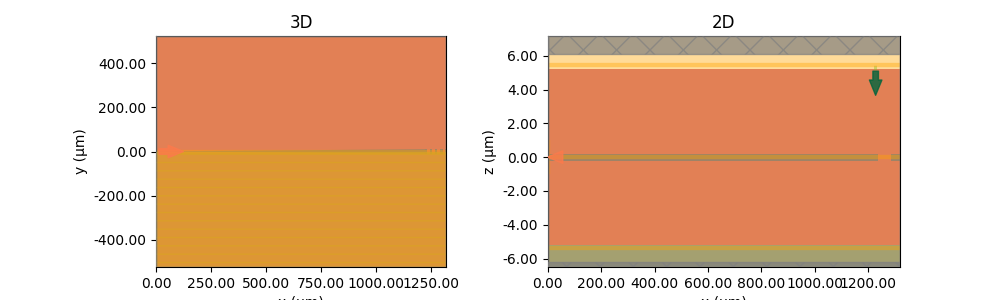

In [7]:
%matplotlib widget
src_pos = 5.0
sim_3d = build_sim(
    sim_mode="visualization",
    sim_dim="3D",
    src_pos=src_pos,
    alpha_t=alpha_t,
    tap_l=tap_l,
    etch_d=h_dev,
    gds_file='./gc_only.gds',
)

sim_2d = build_sim(
    sim_mode="visualization",
    sim_dim="2D",
    src_pos=src_pos,
    alpha_t=alpha_t,
    tap_l=tap_l,
    etch_d=h_dev,
    gds_file='./gc_only.gds',
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.0))
sim_3d.plot(z=h_dev / 2 - etch_d / 2, ax=ax1)
ax1.set_title("3D")
sim_2d.plot(y=0, ax=ax2)
ax2.set_aspect("auto")
ax2.set_title("2D")
plt.show()

02:52:11 Eastern Daylight Time WARNING: Structure at 'structures[3]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

02:58:17 Eastern Daylight Time WARNING: Structure at 'structures[3]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

02:58:19 Eastern Daylight Time WARNING: Simulation final field decay value of   
                               0.317 is greater than the simulation shutoff     
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

                               WARNING: Warning messages were found in the      
                               solver log. For more information, check          
                               'SimulationData.log' or use                      
                               'web.download_log(task_id)'.                     

C:\Users\SiPhox\AppData\Roaming\Python\Python312\site-packages\xarray\core\computation.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


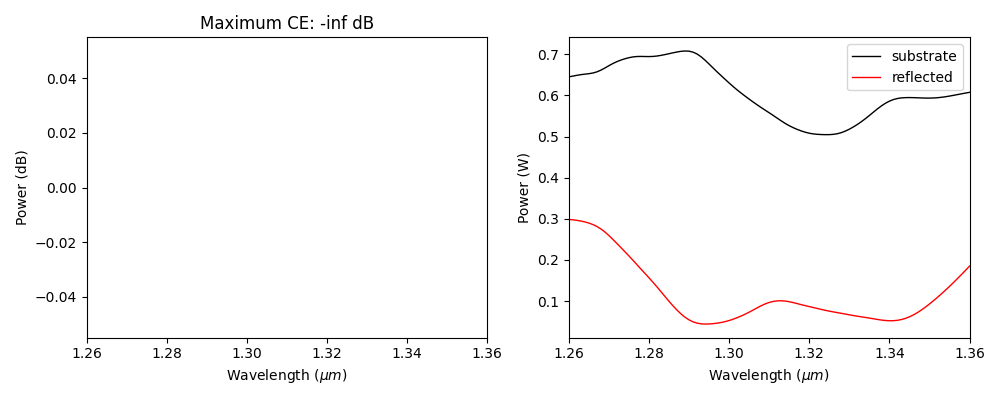

02:58:22 Eastern Daylight Time ERROR: Data after selection has 1 coordinates    
                               (['x']), must be 2 spatial coordinates for       
                               plotting on plane. Please add keyword arguments  
                               to `plot_field()` to select out the other coords.

DataError: Data after selection has 1 coordinates (['x']), must be 2 spatial coordinates for plotting on plane. Please add keyword arguments to `plot_field()` to select out the other coords.

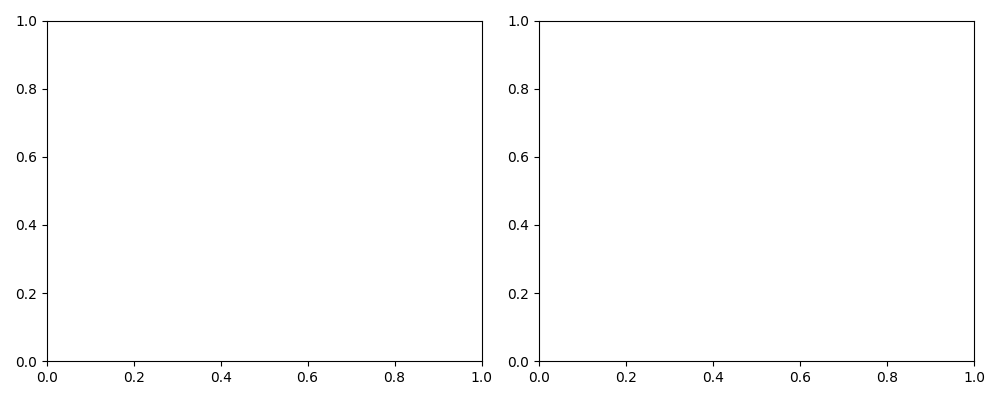

In [12]:
job = web.Job(simulation=sim_2d, task_name="gc_in_coupling_3d", verbose=False)
sim_2d_in = job.run(path="data/gc3d_in_data.hdf5")

# Coupling Efficiency
mode_amps = sim_2d_in["mode_monitor"]
coeffs_f = mode_amps.amps.sel(direction="-")
power = np.abs(coeffs_f.sel(mode_index=0)) ** 2
power_db = 10 * np.log10(power)
ce_3d = np.amax(power_db)
# Fluxes
power_sub = abs(sim_2d_in["flux_sub"].flux)
power_ref = abs(sim_2d_in["flux_reflected"].flux)

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
ax1.plot(wl_range, power_db, color="black", linestyle="solid", linewidth=1.0)
ax1.set_xlim([wl_range[0], wl_range[-1]])
ax1.set_xlabel(r"Wavelength ($\mu m$)")
ax1.set_ylabel("Power (dB)")
ax1.set_title(f"Maximum CE: {ce_3d:.3f} dB")

ax2.plot(
    wl_range,
    power_sub,
    color="black",
    linestyle="solid",
    linewidth=1.0,
    label="substrate",
)

ax2.plot(
    wl_range,
    power_ref,
    color="red",
    linestyle="solid",
    linewidth=1.0,
    label="reflected",
)

ax2.set_xlim([wl_range[0], wl_range[-1]])
ax2.set_xlabel(r"Wavelength ($\mu m$)")
ax2.set_ylabel("Power (W)")
ax2.legend()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
sim_2d_in.plot_field("field_xy", "E", f=freq, val="abs", ax=ax1)
sim_2d_in.plot_field("field_xz", "E", f=freq, val="abs", ax=ax2)
ax2.set_aspect("auto")
plt.show()

In [11]:
# Function to create the simulation.
def build_sim_out(
    sim_mode="sweep",
    sim_dim="3D",
    src_pos=src_pos,
    alpha_t=alpha_t,
    tap_l=tap_l,
    etch_d=etch_d,
    gds_file=[],
):
    
    source_gap = 3  # gap distance between the source and the top oxide
    pd_aperture = 55

    print(gds_file)
    # Build the Tidy3D PolySlab and Structure objects.
    # Get design cell from GDSII file
    gds_path  = gds_file  # File name to export GC GDS file.
    lib_loaded = gdstk.read_gds(gds_path)
    all_cells = {c.name: c for c in lib_loaded.cells}
    print("Cell names: " + ", ".join(all_cells.keys()))
    des_cell = all_cells["GC"]
    print(des_cell)

    gc_cell = des_cell
    wg_t = h_dev  # Waveguide thickness (um).
    etch_d = h_dev  # Etch depth (um).
    wg_l = 1.0
    gc_length = 1316.923 - wg_l # Length of the grating coupler (um).
    print("gc_length: ", gc_length)

    # Calculate the grating coupler parameters.
    gc = td.Geometry.from_gds(
        gc_cell,
        gds_layer=733,
        gds_dtype=727,
        axis=2,
        slab_bounds=(-wg_t / 2, wg_t / 2),
        reference_plane = "bottom",
    )
    gc_struct = td.Structure(
        geometry=gc, medium=mat_si3n4
    )
    gc_offset = wg_w/np.tan(alpha_t*np.pi/180)
    gc_0 = wg_l + tap_l - gc_offset

    # gc_length = tap_l + np.sum(del_x) + tap_e  - gc_offset
    pml_offset = 0.7 * wl
    

    # define a gaussian beam source
    source = td.ModeSource(
        size=(0, td.inf, 6 * wg_t),
        center=(-pml_offset / 2, 0, wg_t / 2),
        source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
        # angle_theta=theta,
        direction="+",
        mode_spec=td.ModeSpec(num_modes=1, target_neff=n_si3n4),
        mode_index=0,
            )
    
    # define a mode monitor to measure coupling efficiency
    flux_monitor = td.FluxMonitor(
        center=[src_pos, 0, h_box + source_gap],
        size=(pd_aperture, td.inf, 0),
        freqs=freqs,
        name="flux",
    )        
    # Simulation size.
    size_z = h_sub + h_box + h_dev + h_clad + pml_offset
    size_x = wg_l + gc_length + wl
    size_y = 0.95 * gc_length * np.tan(alpha_t * np.pi / 180) if sim_dim == "3D" else 0
    center_z = size_z / 2 - pml_offset - h_clad - h_dev / 2

    # Box layer.
    _inf = 1500
    sio2_box = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-_inf, -_inf, -h_dev / 2 - h_box), rmax=(_inf, _inf, -h_dev / 2)
        ),
        medium=mat_sio2,
    )
    # Cladding layer.
    cladding = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-_inf, -_inf, -h_dev / 2), rmax=(_inf, _inf, h_dev / 2 + h_clad)
        ),
        medium=mat_clad,
    )
    # Substrate.
    si_sub = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-_inf, -_inf, -_inf), rmax=(_inf, _inf, -h_dev / 2 - h_box)
        ),
        medium=mat_si,
    )

    if sim_mode == "sweep" or sim_mode == "visualization":
        # Gaussian source focused above the grating coupler.
        source = td.GaussianBeam(
            center=(gc_0 + src_pos, 0, h_dev / 2 + h_clad + src_offset),
            size=(
                1.2 * spot_size,
                1.2 * spot_size if sim_dim == "3D" else td.inf,  # Make it infinity in 2D.
                0,
            ),
            source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
            pol_angle=np.pi / 2,
            angle_theta=theta_f * np.pi / 180.0,
            direction="-",
            num_freqs=7,
            waist_radius=spot_size / 2,
        )
        # Mode monitor.
        mode_spec = td.ModeSpec(num_modes=1, target_neff=n_si3n4)
        mode_monitor = td.ModeMonitor(
            center=[0.5 * wl, 0, 0],
            size=[0, 4 * wg_w, 5 * h_dev],
            freqs=freqs,
            mode_spec=mode_spec,
            name="mode_monitor",
        )
        monitors = [mode_monitor]

        if sim_mode == "visualization":
            # Add field and flux monitors.
            field_monitor_xy = td.FieldMonitor(
                center=(size_x / 2, 0, h_dev / 2 - etch_d / 2),
                size=(td.inf, td.inf, 0),
                freqs=[freq],
                name="field_xy",
            )
            monitors.append(field_monitor_xy)
            field_monitor_xz = td.FieldMonitor(
                center=(size_x / 2, 0, 0),
                size=(td.inf, 0, td.inf),
                freqs=[freq],
                name="field_xz",
            )
            monitors.append(field_monitor_xz)
            flux_sub = td.FluxMonitor(
                center=(size_x / 2, 0, -h_dev - h_box),
                size=(td.inf, td.inf, 0),
                freqs=freqs,
                name="flux_sub",
            )
            monitors.append(flux_sub)
            flux_ref = td.FluxMonitor(
                center=(size_x / 2, 0, h_dev + h_clad + src_offset),
                size=(td.inf, td.inf, 0),
                freqs=freqs,
                name="flux_reflected",
            )
            monitors.append(flux_ref)
    else:
        # Define a mode source that injects te fundamental mode.
        mode_spec = td.ModeSpec(num_modes=1, target_neff=n_si3n4)
        source = td.ModeSource(
            center=(0.5 * wl, 0, 0),
            size=(0, 4 * wg_w, 5 * h_dev),
            source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
            direction="+",
            mode_spec=mode_spec,
            mode_index=0,
            num_freqs=7,
        )
        # Add a near field monitor.
        field_monitor_xy = td.FieldMonitor(
            center=(size_x / 2, 0, h_dev / 2 + h_clad + src_offset),
            size=(td.inf, td.inf, 0),
            freqs=[freq],
            name="near_field",
        )
        monitors = [field_monitor_xy]
        field_monitor_xz = td.FieldMonitor(
            center=(size_x / 2, 0, 0),
            size=(td.inf, 0, td.inf),
            freqs=[freq],
            name="field_xz",
        )
        monitors.append(field_monitor_xz)
        flux_back = td.FluxMonitor(
            center=(0.25 * wl, 0, 0),
            size=(0, td.inf, td.inf),
            freqs=freqs,
            name="flux_back",
        )
        monitors.append(flux_back)

    # Refine the grid over the GC region.
    refine_box = td.MeshOverrideStructure(
        geometry=td.Box(center=(size_x / 2, 0, 0), size=(td.inf, td.inf, 2 * h_dev)),
        dl=[0.02, 0.02 if sim_dim == "3D" else None, 0.02],
    )

    monitors.append(flux_monitor)

    # Simulation
    sim = td.Simulation(
        center=(size_x / 2, 0, -center_z),
        size=(size_x, size_y, size_z),
        grid_spec=td.GridSpec.auto(
            wavelength=wl,
            min_steps_per_wvl=15,
            override_structures=[refine_box],
        ),
        structures=[si_sub, sio2_box, cladding, gc_struct],
        sources=[source],
        monitors=monitors,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.pml()
            if sim_dim == "3D"
            else td.Boundary.periodic(),  # Make it periodic in 2D.
            z=td.Boundary.pml(),
        ),
        symmetry=(0, -1 if sim_dim == "3D" else 0, 0),
        run_time=run_time,
    )
    return sim

In [14]:
%matplotlib widget
src_pos = 5.0
sim_3d_out = build_sim_out(
    sim_mode="visualization",
    sim_dim="3D",
    src_pos=src_pos,
    alpha_t=alpha_t,
    tap_l=tap_l,
    etch_d=h_dev,
    gds_file='./FGC_1.gds',
)

./FGC_1.gds
Cell names: GC
Cell 'GC' with 26 polygons, 0 flexpaths, 0 robustpaths, 0 references, and 0 labels
gc_length:  1315.923


23:29:49 Eastern Daylight Time ERROR: 'flux' (simulation.monitors[5]) is outside
                               of the simulation domain.                        

                               WARNING: Could not execute validator             
                               'check_fixed_angle_components' because field     
                               'monitors' failed validation.                    

ValidationError: 1 validation error for Simulation
monitors
  'flux' (simulation.monitors[5]) is outside of the simulation domain. (type=value_error.setup)